## K-Means Image Segmentation

# 1. Introduction
Mục tiêu

Giới thiệu tổng quan về bài toán và thuật toán sẽ sử dụng.

Nội dung
Image Segmentation là gì?
K-Means Clustering là gì?
Ứng dụng của Image Segmentation.
Mục tiêu của notebook:
Đọc ảnh.
Tiền xử lý.
Phân cụm bằng K-Means.
Tái tạo ảnh.
So sánh kết quả.

# 2. Import Libraries
Mục tiêu Trước khi thực hiện phân đoạn ảnh, cần import các thư viện cần thiết để hỗ trợ đọc ảnh, xử lý dữ liệu, trực quan hóa kết quả và xây dựng mô hình K-Means.

Các thư viện này sẽ được sử dụng xuyên suốt notebook để xử lý ảnh Vịnh Hạ Long và thực hiện các bước phân đoạn ảnh.


In [1]:

import cv2

# Numerical computing
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.cluster import KMeans

2.1 kiểm tra thông tin

# 3. Load Image
Bước này nhằm đọc ảnh đầu vào và kiểm tra xem ảnh đã được tải thành công hay chưa. Đây là bước đầu tiên trong quy trình xử lý ảnh vì toàn bộ các thao tác tiếp theo như tiền xử lý, phân cụm và phân đoạn đều được thực hiện trên ảnh này.

Trong bài thực hành này, ảnh được sử dụng là ảnh phong cảnh Vịnh Hạ Long, bao gồm nhiều vùng màu sắc khác nhau như mặt nước, đảo đá, bầu trời và thuyền. Sự khác biệt về màu sắc giữa các vùng sẽ giúp thuật toán K-Means phân cụm hiệu quả hơn.


3.1 Read Image

In [2]:
# Read image
image = cv2.imread("halong.jpg")

# Check if the image is loaded successfully
if image is None:
    print("Error: Cannot load the image!")
else:
    print("Image loaded successfully!")

Image loaded successfully!


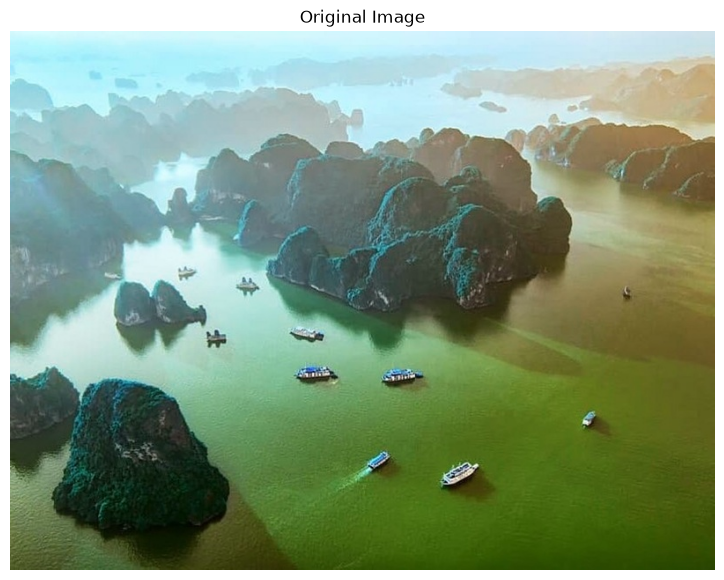

In [3]:

plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

# 4. Explore Image
Mục đích

Khám phá các đặc điểm cơ bản của ảnh trước khi tiền xử lý. Bước này giúp xác định kích thước ảnh, kiểu dữ liệu và cấu trúc của từng pixel để chuẩn bị cho thuật toán K-Means.

4.1 Image Dimensions
Giải thích

Kiểm tra kích thước của ảnh để biết chiều cao, chiều rộng và số kênh màu. Đối với ảnh RGB, số kênh màu sẽ là 3.

In [4]:
# Display image dimensions
height, width, channels = image.shape

print(f"Height   : {height} pixels")
print(f"Width    : {width} pixels")
print(f"Channels : {channels}")

Height   : 612 pixels
Width    : 800 pixels
Channels : 3


4.2 Image Data 

Kiểm tra kiểu dữ liệu của ảnh. Thông thường ảnh có kiểu uint8, nghĩa là mỗi giá trị màu nằm trong khoảng từ 0 đến 255.

In [5]:
# Display image data type
print("Data Type:", image.dtype)

Data Type: uint8


4.3 Pixel Value Range

Mỗi pixel trong ảnh RGB được biểu diễn bởi ba giá trị (R, G, B). Đây cũng chính là ba đặc trưng mà thuật toán K-Means sẽ sử dụng để phân cụm.

In [6]:
# Display the first pixel value
print("First pixel (RGB):", image[0, 0])

# Display the first 5 pixels
print("\nFirst 5 pixels:")
print(image.reshape(-1, 3)[:5])

First pixel (RGB): [213 250 254]

First 5 pixels:
[[213 250 254]
 [212 249 253]
 [212 249 253]
 [212 249 253]
 [215 250 254]]


# 5. Image Preprocessing
Chuẩn bị dữ liệu ảnh trước khi áp dụng thuật toán K-Means. Ở bước này, ảnh sẽ được thay đổi kích thước để giảm thời gian xử lý, sau đó chuyển thành ma trận hai chiều để mỗi pixel được biểu diễn dưới dạng một vector màu (R, G, B).

5.1 Resize Image
Giải thích

Ảnh gốc có kích thước khá lớn nên việc xử lý sẽ tốn nhiều thời gian. Vì vậy, ảnh được resize về 300 × 300 pixels nhằm giảm số lượng pixel nhưng vẫn giữ được các đặc điểm chính của ảnh.



5.2 Flatten Image
Giải thích

Thuật toán K-Means không làm việc trực tiếp với ảnh ba chiều (Height, Width, 3). Do đó, ảnh được chuyển thành ma trận hai chiều (Number of Pixels, 3), trong đó mỗi hàng tương ứng với một pixel và ba cột là giá trị R, G, B.

5.3 Verify Preprocessed Data


Kiểm tra lại kích thước của ảnh sau khi resize và dữ liệu pixel sau khi flatten để đảm bảo dữ liệu đã đúng định dạng trước khi thực hiện phân cụm.

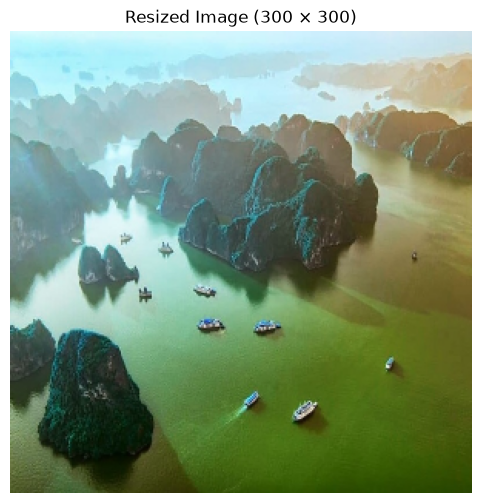

Resized Image Shape : (300, 300, 3)
Pixel Matrix Shape  : (90000, 3)

First Pixel (RGB): [212 249 253]

First 5 Pixels:
[[212 249 253]
 [212 249 253]
 [216 251 255]
 [215 250 254]
 [215 250 254]]


In [7]:
# ==========================================
# Image Preprocessing
# ==========================================

# Resize image
resized_image = cv2.resize(image, (300, 300))

# Display resized image
plt.figure(figsize=(6,6))
plt.imshow(resized_image)
plt.title("Resized Image (300 × 300)")
plt.axis("off")
plt.show()

# Flatten image into a 2D array
pixels = resized_image.reshape((-1, 3))

# Display preprocessing information
print("Resized Image Shape :", resized_image.shape)
print("Pixel Matrix Shape  :", pixels.shape)

print("\nFirst Pixel (RGB):", pixels[0])

print("\nFirst 5 Pixels:")
print(pixels[:5])

# 6. Apply K-Means Clustering
Mục đích

Áp dụng thuật toán K-Means để phân cụm các pixel trong ảnh dựa trên sự tương đồng về màu sắc. Mỗi cụm sẽ được đại diện bởi một centroid, là màu trung bình của các pixel thuộc cụm đó.

6.1 Select Number of Clusters

Giá trị K là số cụm màu mà thuật toán sẽ tạo ra. Trong bài này, chọn K = 5 để phân đoạn ảnh thành 5 vùng màu chính.

In [8]:

k = 5

print("Number of Clusters:", k)

Number of Clusters: 5


6.2 Train K-Means Model
Giải thích

Sau khi khởi tạo các centroid ban đầu, thuật toán K-Means sẽ thực hiện lặp lại hai bước:

Gán mỗi pixel vào cụm có centroid gần nhất.
Cập nhật centroid bằng giá trị trung bình (mean) của tất cả các pixel thuộc cụm đó.

Quá trình này được lặp lại cho đến khi các centroid không còn thay đổi hoặc đạt số vòng lặp tối đa.

In [35]:
# Initialize K-Means model
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

# Train the model
kmeans.fit(pixels)


,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](8, 3)","[[193

In [37]:
# Number of iterations until convergence
print("Number of Iterations:", kmeans.n_iter_)

Number of Iterations: 57


6.3 Cluster Assignment

Sau khi huấn luyện, mỗi pixel sẽ được gán vào cụm có centroid gần nhất. Kết quả được lưu trong biến labels

In [10]:
# Get cluster labels
labels = kmeans.labels_

print("First 20 Cluster Labels:")
print(labels[:20])

First 20 Cluster Labels:
[3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


6.4 Cluster Centers
Giải thích

Sau khi hoàn thành quá trình phân cụm, thuật toán K-Means sẽ tính centroid cho mỗi cụm. Mỗi centroid là màu trung bình của các pixel trong cụm và sẽ được sử dụng để thay thế màu của các pixel khi tạo ảnh phân đoạn.

In [11]:
# Get cluster centers
centers = kmeans.cluster_centers_.astype(np.uint8)

print("Cluster Centers (RGB):")
print(centers)

print("\nCenters Shape:", centers.shape)

Cluster Centers (RGB):
[[ 43  61  25]
 [164 194 181]
 [ 87 106  45]
 [192 234 240]
 [118 141 117]]

Centers Shape: (5, 3)


6.5 Visualize Cluster Centers

Để dễ quan sát, các centroid sẽ được hiển thị dưới dạng các ô màu. Mỗi ô màu đại diện cho màu trung bình của một cụm mà thuật toán K-Means đã tìm được.

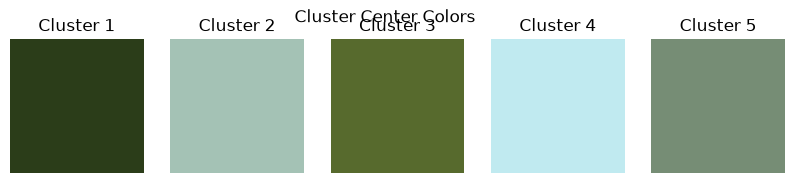

In [12]:
# Display cluster center colors
plt.figure(figsize=(10, 2))

for i, color in enumerate(centers):
    plt.subplot(1, len(centers), i + 1)
    plt.imshow([[color]])
    plt.title(f"Cluster {i+1}")
    plt.axis("off")

plt.suptitle("Cluster Center Colors")
plt.show()

# 7. Image Segmentation
Mục đích

Tạo ảnh phân đoạn bằng cách thay thế màu của mỗi pixel bằng màu centroid của cụm mà pixel đó được gán vào. Sau đó, dữ liệu sẽ được chuyển về kích thước ảnh ban đầu để hiển thị.

7.1 Replace Pixel Colors

Mỗi pixel sẽ được thay thế bằng màu của Cluster Center tương ứng. Điều này giúp các pixel trong cùng một cụm có cùng màu, tạo thành các vùng màu rõ ràng trên ảnh.

In [13]:
# Replace each pixel with its cluster center
segmented_pixels = centers[labels]

print("Segmented Pixels Shape:", segmented_pixels.shape)

print("\nFirst 5 Segmented Pixels:")
print(segmented_pixels[:5])

Segmented Pixels Shape: (90000, 3)

First 5 Segmented Pixels:
[[192 234 240]
 [192 234 240]
 [192 234 240]
 [192 234 240]
 [192 234 240]]


7.2 Reshape


Sau khi thay thế màu của từng pixel, dữ liệu vẫn ở dạng ma trận (90000, 3). Trước tiên, dữ liệu được chuyển về kích thước của ảnh đã resize (300, 300, 3). Sau đó, ảnh được resize trở lại kích thước ban đầu để đáp ứng yêu cầu của bài toán và thuận tiện cho việc so sánh với ảnh gốc.

In [38]:
# Reshape to resized image dimensions
segmented_image = segmented_pixels.reshape(resized_image.shape)

# Restore to original image size
segmented_image_original = cv2.resize(
    segmented_image,
    (image.shape[1], image.shape[0])
)

print("Segmented Image Shape (Resized):", segmented_image.shape)
print("Segmented Image Shape (Original):", segmented_image_original.shape)

Segmented Image Shape (Resized): (300, 300, 3)
Segmented Image Shape (Original): (612, 800, 3)


7.3 Display Segmented Image
Giải thích

Hiển thị ảnh sau khi phân đoạn để quan sát kết quả. Lúc này, các pixel có màu sắc tương tự đã được gom thành cùng một cụm màu.

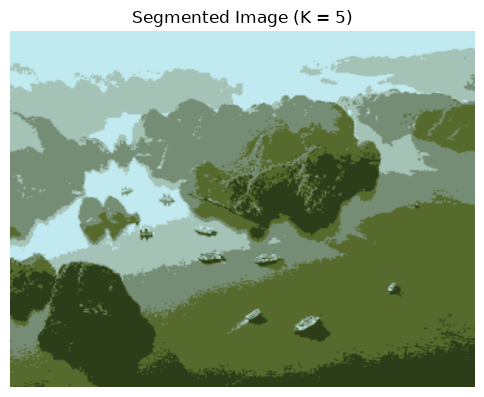

In [28]:
# Display segmented image
plt.figure(figsize=(6,6))
plt.imshow(segmented_image_original)
plt.title("Segmented Image (K = 5)")
plt.axis("off")
plt.show()

# 8. Visualization
Mục đích

So sánh trực quan giữa ảnh gốc và ảnh sau khi phân đoạn để đánh giá hiệu quả của thuật toán K-Means.

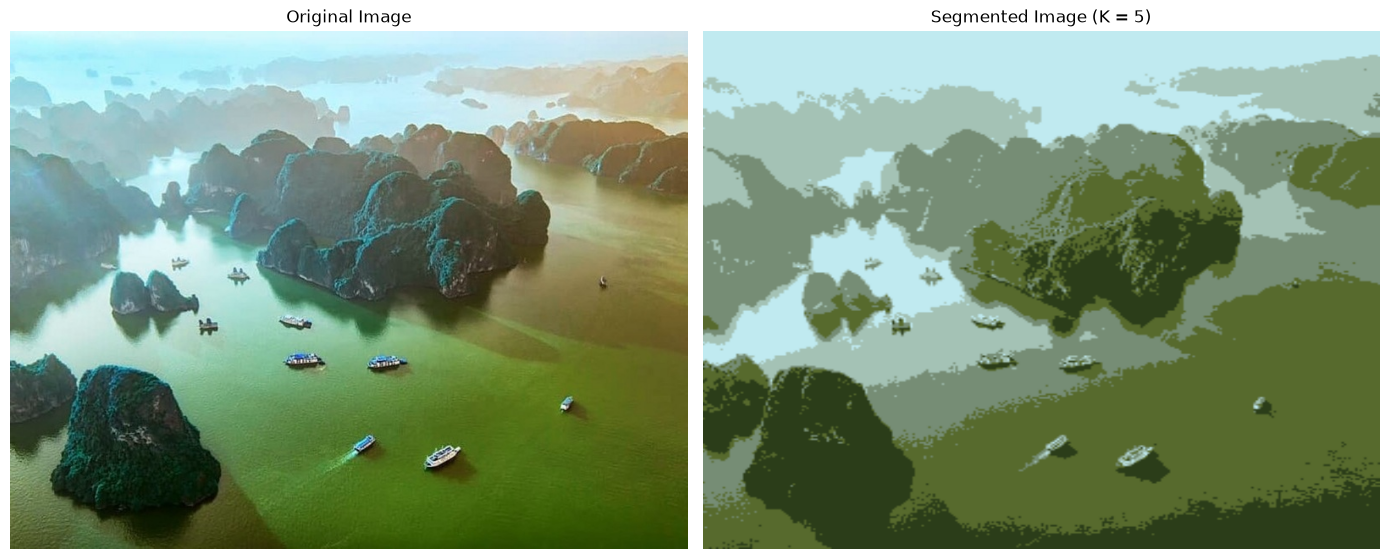

In [ ]:

plt.figure(figsize=(14, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(image)         
plt.title("Original Image")
plt.axis("off")

# Segmented Image
plt.subplot(1, 2, 2)
plt.imshow(segmented_image_original)
 
plt.title("Segmented Image (K = 5)")
plt.axis("off")

plt.tight_layout()
plt.show()

# 9. Compare Different K Values
**Mục đích**

Thuật toán K-Means sẽ được thực hiện với các giá trị K = 2, 4, 6 và 8. Sau đó, kết quả sẽ được so sánh để đánh giá mức độ giữ lại chi tiết và khả năng phân biệt các vùng trong ảnh.

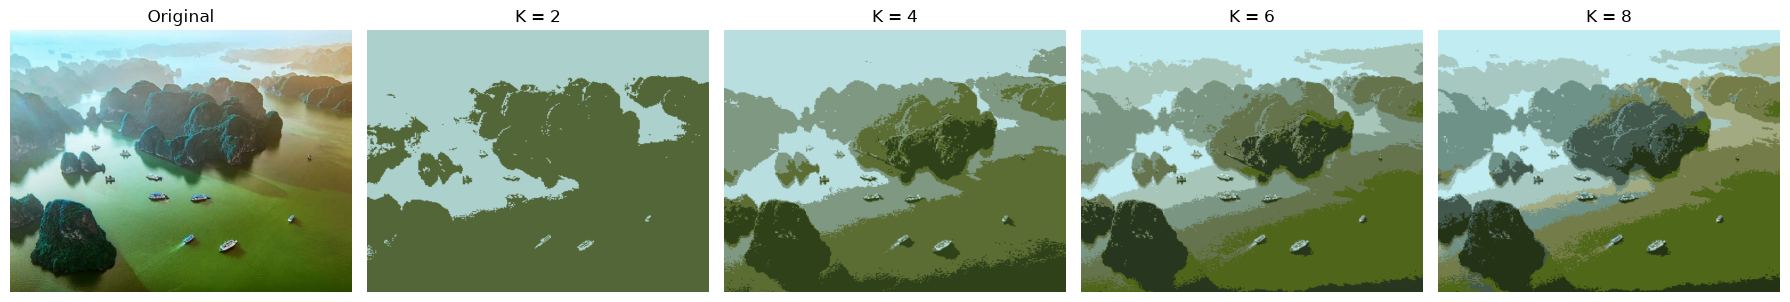

In [31]:
# ==========================================
# Compare Different K Values
# ==========================================

k_values = [2, 4, 6, 8]

plt.figure(figsize=(18, 5))

# Original Image
plt.subplot(1, len(k_values) + 1, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

for i, k in enumerate(k_values):

    # K-Means model
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Train model
    labels = kmeans.fit_predict(pixels)

    # Cluster centers
    centers = kmeans.cluster_centers_.astype(np.uint8)

    # Replace each pixel with centroid
    segmented = centers[labels]

    # Reshape to image
    segmented = segmented.reshape(resized_image.shape)

    # Restore to original size
    segmented = cv2.resize(
        segmented,
        (image.shape[1], image.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    # Display
    plt.subplot(1, len(k_values) + 1, i + 2)
    plt.imshow(segmented)
    plt.title(f"K = {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

| Giá trị K | Đặc điểm                               | Đánh giá               |
| --------- | -------------------------------------- | ---------------------- |
| **K = 2** | Ít màu, mất nhiều chi tiết             | Chưa phù hợp           |
| **K = 4** | Bắt đầu tách các vùng màu              | Khá tốt                |
| **K = 6** | Giữ được nhiều chi tiết                | Tốt                    |
| **K = 8** | Rất nhiều chi tiết, gần ảnh gốc        | Đơn giản hóa kém       |
| **K = 5** | Cân bằng giữa chi tiết và số lượng màu | **lựa chọn**|


# 10. Discussion
**Mục đích**

Đánh giá hiệu quả của thuật toán K-Means trong bài toán phân đoạn ảnh và phân tích ảnh hưởng của việc lựa chọn số cụm K đến kết quả.

**Nhận xét**

Thuật toán K-Means hoạt động tốt đối với ảnh Vịnh Hạ Long. Các vùng có màu sắc tương đồng như mặt nước, đảo đá và bầu trời được phân cụm khá rõ ràng. Ảnh sau khi phân đoạn vẫn giữ được các đặc điểm chính, đồng thời giảm số lượng màu để việc quan sát trở nên đơn giản 

Qua quá trình thử nghiệm với các giá trị K = 2, 4, 6 và 8, có thể thấy K = 5 là lựa chọn phù hợp nhất cho bài thực hành. Giá trị này tạo được sự cân bằng giữa việc giữ lại chi tiết và đơn giản hóa ảnh, giúp các vùng chính trong ảnh được phân biệt rõ ràng.

Ưu điểm của K-Means
Nhận xét
Thuật toán đơn giản và dễ triển khai.
Thời gian xử lý nhanh đối với ảnh có kích thước vừa phải.
Phân đoạn tốt các vùng có màu sắc tương đồng.
Dễ điều chỉnh thông qua tham số K.

Hạn chế của K-Means
Nhận xét
Cần xác định trước số cụm K.
Chỉ dựa trên màu sắc nên có thể gộp các đối tượng khác nhau nếu chúng có màu tương tự.
Kết quả có thể thay đổi nếu lựa chọn K không phù hợp.
Không tận dụng được thông tin về vị trí hoặc hình dạng của các đối tượng trong ảnh.

**Kết quả**

Qua quá trình thực nghiệm, thuật toán K-Means cho kết quả phân đoạn tốt đối với ảnh Vịnh Hạ Long. Tuy nhiên, chất lượng phân đoạn phụ thuộc nhiều vào việc lựa chọn giá trị K. Với bài thực hành này, K = 5 cho kết quả trực quan và phù hợp nhất.


# 11. Conclusion
**Mục đích**

Tổng kết toàn bộ quá trình thực hiện bài toán phân đoạn ảnh bằng thuật toán K-Means và đánh giá kết quả đạt được.

**Tóm tắt quá trình thực hiện**

Trong notebook này, ảnh đầu vào đã được đọc và tiền xử lý bằng cách chuyển đổi không gian màu, thay đổi kích thước và chuyển thành ma trận dữ liệu phù hợp với thuật toán K-Means. Sau đó, thuật toán được áp dụng để phân cụm các pixel dựa trên giá trị màu sắc và tạo ra ảnh sau khi phân đoạn.

**Đánh giá kết quả**

Kết quả thực nghiệm cho thấy thuật toán K-Means có khả năng phân đoạn ảnh khá hiệu quả. Các vùng có màu sắc tương đồng như mặt nước, đảo đá và bầu trời được nhóm thành các cụm màu riêng biệt, giúp đơn giản hóa ảnh nhưng vẫn giữ được những đặc điểm quan trọng.

**Vai trò của tham số K**

Giá trị K ảnh hưởng trực tiếp đến chất lượng phân đoạn. Khi K quá nhỏ, nhiều vùng màu khác nhau bị gộp lại làm mất chi tiết. Ngược lại, khi K quá lớn, ảnh giữ lại nhiều chi tiết hơn nhưng mức độ đơn giản hóa giảm. Trong bài thực hành này, K = 5 được đánh giá là phù hợp nhất với ảnh Vịnh Hạ Long.

**Hướng phát triển**

Để nâng cao chất lượng phân đoạn, có thể thử sử dụng các không gian màu khác như HSV hoặc LAB thay cho RGB. Ngoài ra, có thể áp dụng các thuật toán phân cụm khác như Mean Shift, DBSCAN hoặc Gaussian Mixture Model (GMM) để so sánh và đánh giá hiệu quả.

**Kết luận**

Thuật toán K-Means là một phương pháp đơn giản, dễ triển khai và có khả năng phân đoạn ảnh hiệu quả dựa trên màu sắc. Mặc dù vẫn còn một số hạn chế, nhưng đây là một lựa chọn phù hợp cho các bài toán phân đoạn ảnh cơ bản và là nền tảng để nghiên cứu các phương pháp phân đoạn ảnh nâng cao hơn.